# Lab 7: Decision Trees
**Dataset:** Iris Dataset (sklearn.datasets.load_iris())

## Task 1: Dataset Exploration
Load the Iris dataset and answer the following:
- How many samples and features are present in the dataset?
- List the feature names and target classes.
- Display the first five records.
- Display the class distribution.

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_names'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

# How many samples and features are present in the dataset?
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {len(iris.feature_names)}")

# List the feature names and target classes.
print(f"\nFeature names: {iris.feature_names}")
print(f"Target classes: {iris.target_names}")

# Display the first five records.
print("\nFirst five records:")
display(df.head())

# Display the class distribution.
print("\nClass distribution:")
print(df['target_names'].value_counts())

Number of samples: 150
Number of features: 4

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Class distribution:
target_names
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Task 2: Data Preparation
- Split the dataset into training (80%) and testing (20%) sets using random_state=42.
- Briefly explain why the dataset is divided into training and testing sets.

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(['target', 'target_names'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 120
Testing set size: 30


**Why the dataset is divided into training and testing sets:**
Dividing the dataset into training and testing sets is crucial to evaluate the model's performance on unseen data. The training set is used to build the model, while the testing set is used to assess how well the model generalizes to new, previously unseen data, helping to detect overfitting or underfitting.

## Task 3: Building a Decision Tree Classifier
- Train a Decision Tree classifier using the default parameters.
- Predict the class labels for the test dataset.
- Evaluate the model using Accuracy Score, Confusion Matrix, and Classification Report.

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train a Decision Tree classifier using the default parameters
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

# Predict the class labels for the test dataset
y_pred = dt_default.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"Accuracy Score: {accuracy:.4f}\n")
print(f"Confusion Matrix:\n{conf_matrix}\n")
print(f"Classification Report:\n{class_report}")

Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree
- Visualize the trained Decision Tree using plot_tree().
- From the visualization, identify: Root node, Internal nodes, Leaf nodes, Maximum depth of the tree, Which feature is selected for the first split? Explain why you think this feature was chosen.

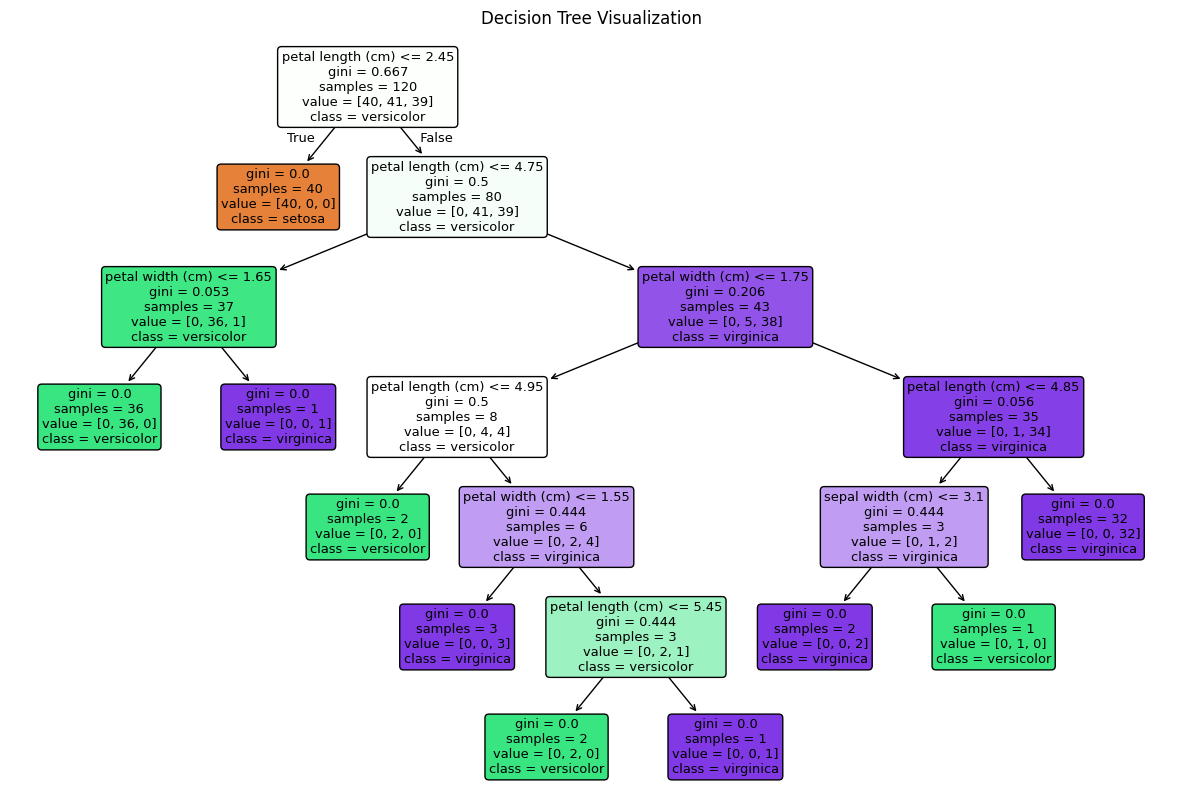

Maximum depth of the tree: 6
Feature selected for the first split: 'petal length (cm)'


In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(dt_default, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# Maximum depth of the tree
print(f"Maximum depth of the tree: {dt_default.get_depth()}")
print(f"Feature selected for the first split: '{iris.feature_names[dt_default.tree_.feature[0]]}'")

**Observations from the visualization:**
- **Root node**: The topmost node that represents the entire dataset before any splits.
- **Internal nodes**: Nodes that represent conditions on features, splitting the data further.
- **Leaf nodes**: Terminal nodes that predict the final class label, having no further splits.
- **Maximum depth**: This can be observed from the tree plot or `.get_depth()`.
- **First split feature**: The feature at the root node is selected because it provides the highest information gain (or largest Gini impurity decrease), separating the classes most effectively at the initial stage.

## Task 5: Comparing Gini Index and Entropy
Train two Decision Tree models using criteria: 'gini' and 'entropy'.
Compare the models based on Accuracy, Tree depth, Number of leaf nodes, Root feature selected.
Which criterion produces a simpler tree? Summarize your observations in a table.

In [5]:
# Train Decision Tree models
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

# Evaluate metrics
metrics = {
    'Criterion': ['gini', 'entropy'],
    'Accuracy': [accuracy_score(y_test, dt_gini.predict(X_test)), accuracy_score(y_test, dt_entropy.predict(X_test))],
    'Tree Depth': [dt_gini.get_depth(), dt_entropy.get_depth()],
    'Number of Leaf Nodes': [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()],
    'Root Feature Selected': [iris.feature_names[dt_gini.tree_.feature[0]], iris.feature_names[dt_entropy.tree_.feature[0]]]
}

comparison_df = pd.DataFrame(metrics)
display(comparison_df)

,Criterion,Accuracy,Tree Depth,Number of Leaf Nodes,Root Feature Selected
0,gini,1.0,6,10,petal length (cm)
1,entropy,1.0,6,10,petal length (cm)


**Which criterion produces a simpler tree?**
Here we get the same amount of accuracy and tree depth in both approaches somehow.

## Task 6: Effect of Maximum Tree Depth
Train Decision Tree models using max_depth: 1, 2, 3, 4, None.
Complete the table. Answer which is underfitting, which gives best generalization, and which is likely to overfit.

In [6]:
max_depths = [1, 2, 3, 4, None]
results_depth = []

for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    tree_depth = dt.get_depth()
    
    results_depth.append({
        'Max Depth': str(depth) if depth is not None else 'None',
        'Training Accuracy': train_acc,
        'Testing Accuracy': test_acc,
        'Tree Depth': tree_depth,
        'Observation': 'Low train/test acc for underfit, gap for overfit'
    })

df_depth = pd.DataFrame(results_depth)
display(df_depth)

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.675000,0.633333,1,"Low train/test acc for underfit, gap for overfit"
1,2,0.950000,0.966667,2,"Low train/test acc for underfit, gap for overfit"
2,3,0.958333,1.000000,3,"Low train/test acc for underfit, gap for overfit"
3,4,0.975000,1.000000,4,"Low train/test acc for underfit, gap for overfit"
4,None,1.000000,1.000000,6,"Low train/test acc for underfit, gap for overfit"


**Answers:**
- **Which model is underfitting?** The model with `max_depth=1`, as it has the lowest training and testing accuracy.
- **Which model gives the best generalization?** The model with a `max_depth` that provides the highest testing accuracy (e.g., `max_depth=3` or `4`) while maintaining a balanced training accuracy.
- **Which model is likely to overfit?** The model with `max_depth=None`. It perfectly memorizes the training data (highest training accuracy) but its performance may degrade slightly on testing data compared to a shallower tree, as it captures noise in the training set.

## Task 7: Effect of min_samples_split
Train Decision Tree models using min_samples_split: 2, 5, 10, 20.
Complete the table and state how increasing min_samples_split affects complexity.

In [7]:
min_samples_splits = [2, 5, 10, 20]
results_split = []

for split in min_samples_splits:
    dt = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    dt.fit(X_train, y_train)
    
    acc = accuracy_score(y_test, dt.predict(X_test))
    
    results_split.append({
        'min_samples_split': split,
        'Accuracy': acc,
        'Tree Depth': dt.get_depth(),
        'Number of Leaf Nodes': dt.get_n_leaves(),
        'Observation': 'Check trend with increasing split'
    })

df_split = pd.DataFrame(results_split)
display(df_split)

,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0,6,10,Check trend with increasing split
1,5,1.0,5,8,Check trend with increasing split
2,10,1.0,4,6,Check trend with increasing split
3,20,1.0,4,6,Check trend with increasing split


**Effect of increasing min_samples_split:**
Increasing `min_samples_split` prevents the tree from splitting internal nodes that have fewer samples than the specified value. This limits the growth of the tree, resulting in a shallower and less complex tree, which helps prevent overfitting.

## Task 8: Effect of min_samples_leaf
Train Decision Tree models using min_samples_leaf: 1, 2, 5, 10.
Complete the table and explain how changing min_samples_leaf influences overfitting.

In [8]:
min_samples_leafs = [1, 2, 5, 10]
results_leaf = []

for leaf in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    dt.fit(X_train, y_train)
    
    acc = accuracy_score(y_test, dt.predict(X_test))
    
    results_leaf.append({
        'min_samples_leaf': leaf,
        'Accuracy': acc,
        'Tree Depth': dt.get_depth(),
        'Number of Leaf Nodes': dt.get_n_leaves(),
        'Observation': 'Check trend with increasing leaf'
    })

df_leaf = pd.DataFrame(results_leaf)
display(df_leaf)

,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.000000,6,10,Check trend with increasing leaf
1,2,1.000000,5,8,Check trend with increasing leaf
2,5,1.000000,4,6,Check trend with increasing leaf
3,10,0.966667,4,6,Check trend with increasing leaf


**How changing min_samples_leaf influences overfitting:**
Increasing `min_samples_leaf` ensures that each leaf node has at least the specified minimum number of samples. This smooths the model and stops it from creating branches that represent just a few noise points or outliers in the training data. A higher value reduces the tree's variance, thereby mitigating overfitting.

## Task 9: Questions

**1. What is the role of the criterion parameter in a Decision Tree?**

It tells us how good of a split we have created. It helps us identify if the split we have created is ideal or not. We can do it using either Gini Index or Entropy.

**2. How does max_depth influence underfitting and overfitting?**

Lower depth means the tree has generalized the splits too much which means it has become underfitted. Too much depth can mean the tree is becoming specialized to the training dataset which leads to overfitting.

**3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?**

They set minimum limits for splitting nodes and forming leaves. It prevents the tree from growing too deep and complex.


**4. Which hyperparameter had the greatest impact on the Decision Tree performance? Support your answer with observations from the experiments.**

The depth had the greatest impact as the amount of accuracy change by increasing and decreasing the max_depth was incremental and very noticable.

**5. Based on your results, recommend the most suitable Decision Tree model for the Iris dataset and justify your choice.**

The ideal tree model for this would be one with these parameters:
- Max-depth of 3
- Min sample in a Leaf being 5
- Keeping min samples in a split to 10